In [32]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

In [33]:
base = Path("../data/raw")

customer_df = pd.read_excel(base / "customer_data.xlsx")
sales_df = pd.read_excel(base / "sales_data.xlsx")
shopping_df = pd.read_excel(base / "shopping_mall_data.xlsx")

display(customer_df.head())
display(sales_df.head())
display(shopping_df.head())

,customer_id,gender,age,payment_method
0,C241288,Female,28.0,Credit Card
1,C111565,Male,21.0,Debit Card
2,C266599,Male,20.0,Cash
3,C988172,Female,66.0,Credit Card
4,C189076,Female,53.0,Cash


,invoice_no,customer_id,category,quantity,invoice date,price,shopping_mall
0,I138884,C241288,Clothing,5,05/08/2022,1500.40,South Coast Plaza
1,I317333,C111565,Shoes,3,12/12/2021,1800.51,Beverly Center
2,I127801,C266599,Clothing,1,09/11/2021,300.08,Westfield Century City
3,I173702,C988172,Shoes,5,05/16/2021,3000.85,Stanford Shopping Center
4,I337046,C189076,Books,4,10/24/2021,60.60,South Coast Plaza


,shopping_mall,construction_year,area (sqm),location,store_count
0,South Coast Plaza,1967,250000,Costa Mesa,270
1,Westfield Valley Fair,1986,220000,Santa Clara,230
2,The Grove,2002,56000,Los Angeles,140
3,Westfield Century City,1964,133000,Los Angeles,200
4,Beverly Center,1982,111000,Los Angeles,160


In [34]:
customer_df.info()
sales_df.info()
shopping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     99457 non-null  object 
 1   gender          99457 non-null  object 
 2   age             99338 non-null  float64
 3   payment_method  99457 non-null  object 
dtypes: float64(1), object(3)
memory usage: 3.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_no     99457 non-null  object 
 1   customer_id    99457 non-null  object 
 2   category       99457 non-null  object 
 3   quantity       99457 non-null  int64  
 4   invoice date   99457 non-null  object 
 5   price          99457 non-null  float64
 6   shopping_mall  99457 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 5.3+ MB
<cla

In [35]:
customer_df.describe()

,age
count,99338.000000
mean,43.425859
std,14.989400
min,18.000000
25%,30.000000
50%,43.000000
75%,56.000000
max,69.000000


In [36]:
sales_df.describe()

,quantity,price
count,99457.000000,99457.000000
mean,3.003429,689.256321
std,1.413025,941.184567
min,1.000000,5.230000
25%,2.000000,45.450000
50%,3.000000,203.300000
75%,4.000000,1200.320000
max,5.000000,5250.000000


In [37]:
shopping_df.describe()

,construction_year,area (sqm),store_count
count,10.000000,10.000000,10.000000
mean,1976.600000,154800.000000,186.000000
std,14.982953,61450.612509,45.264654
min,1956.000000,56000.000000,130.000000
25%,1964.750000,120000.000000,145.000000
50%,1976.500000,139000.000000,185.000000
75%,1985.000000,205250.000000,215.000000
max,2002.000000,250000.000000,270.000000


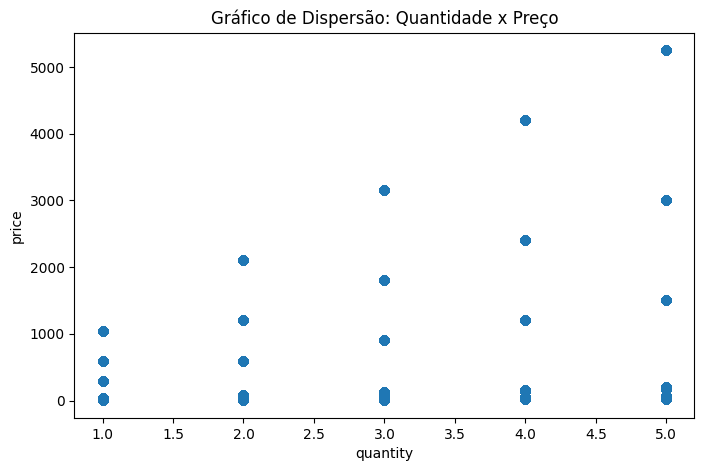

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(sales_df["quantity"], sales_df["price"], alpha=0.5)
plt.title("Gráfico de Dispersão: Quantidade x Preço")
plt.xlabel("quantity")
plt.ylabel("price")
plt.show()

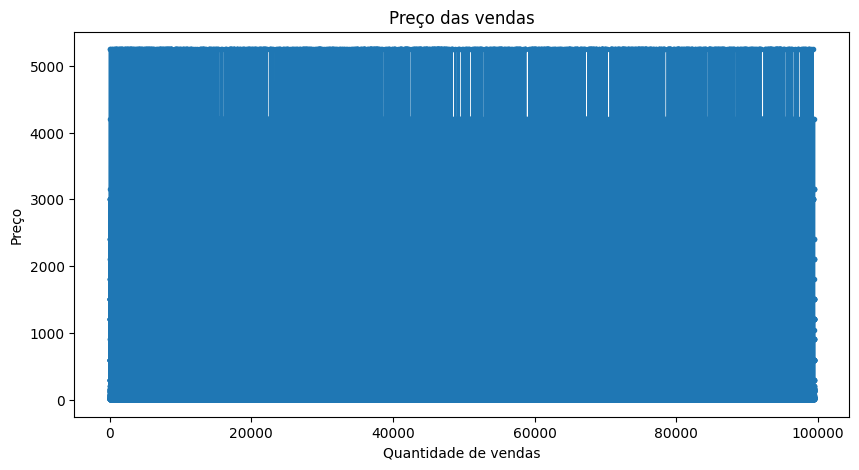

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sales_df["price"], marker="o", linestyle="-", markersize=3)
ax.set_title("Preço das vendas")
ax.set_xlabel("Quantidade de vendas")
ax.set_ylabel("Preço")
plt.show()

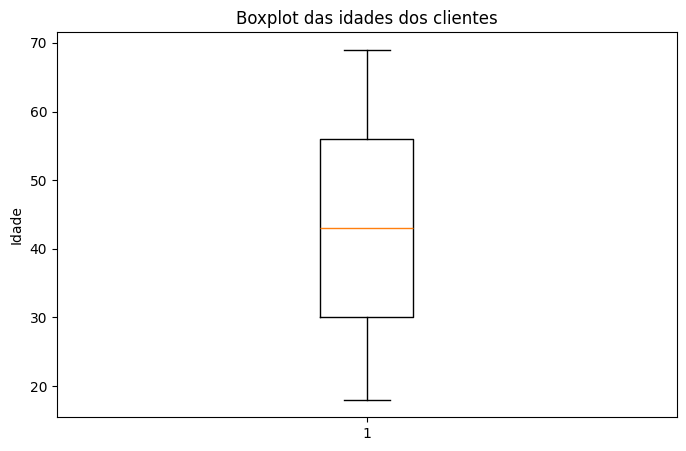

In [40]:
plt.figure(figsize=(8, 5))
plt.boxplot(customer_df["age"].dropna())
plt.title("Boxplot das idades dos clientes")
plt.ylabel("Idade")
plt.show()

In [41]:
count = sales_df["category"].value_counts()
print(count)

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64


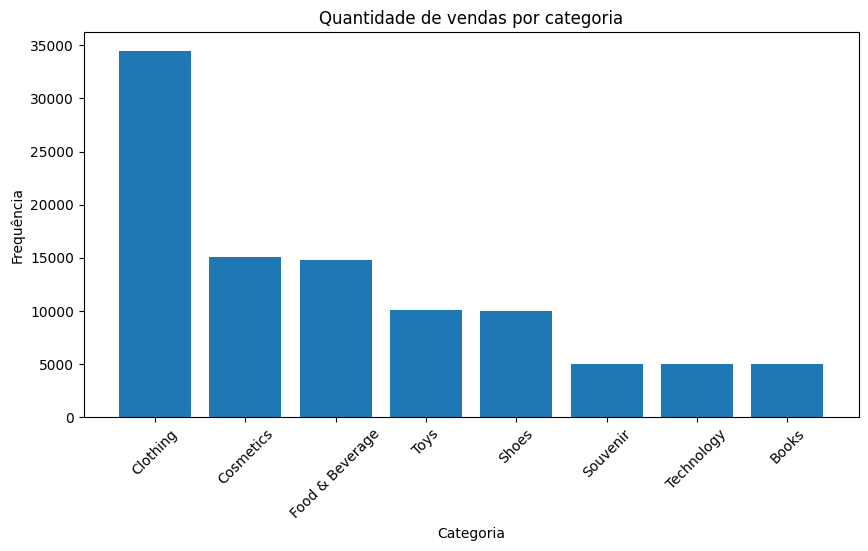

In [44]:
count = sales_df["category"].value_counts()

labels = count.index
values = count.values

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values)

ax.set_title("Quantidade de vendas por categoria")
ax.set_xlabel("Categoria")
ax.set_ylabel("Frequência")
plt.xticks(rotation=45)
plt.show()

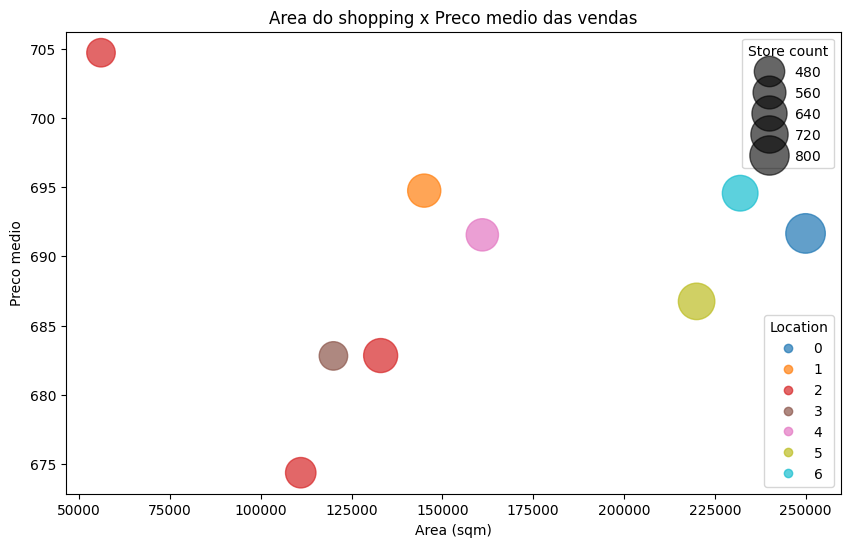

In [43]:
df_mall = sales_df.merge(shopping_df, on="shopping_mall", how="inner")

resumo = (
    df_mall.groupby(["shopping_mall", "location", "area (sqm)", "store_count"], as_index=False)
    .agg(preco_medio=("price", "mean"))
)

cores = resumo["location"].astype("category").cat.codes
tamanhos = resumo["store_count"] * 3

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(resumo["area (sqm)"], resumo["preco_medio"], c=cores, s=tamanhos, alpha=0.7, cmap="tab10")

ax.set_title("Area do shopping x Preco medio das vendas")
ax.set_xlabel("Area (sqm)")
ax.set_ylabel("Preco medio")

legend1 = ax.legend(*scatter.legend_elements(), title="Location", loc="lower right")
ax.add_artist(legend1)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=5)
ax.legend(handles, labels, title="Store count", loc="upper right")

plt.show()